<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               200 non-null    object 
 1   Year                                  200 non-null    int64  
 2   Air_Pollution_Index                   200 non-null    float64
 3   Water_Pollution_Index                 200 non-null    float64
 4   Soil_Pollution_Index                  200 non-null    float64
 5   Industrial_Waste_in_tons              200 non-null    float64
 6   Energy_Recovered_in_GWh               200 non-null    float64
 7   CO2_Emissions_in_MT                   200 non-null    float64
 8   Renewable_Energy_percent              200 non-null    float64
 9   Plastic_Waste_Produced_in_tons        200 non-null    float64
 10  Energy_Consumption_Per_Capita_in_MWh  200 non-null    float64
 11  Population_in_milli

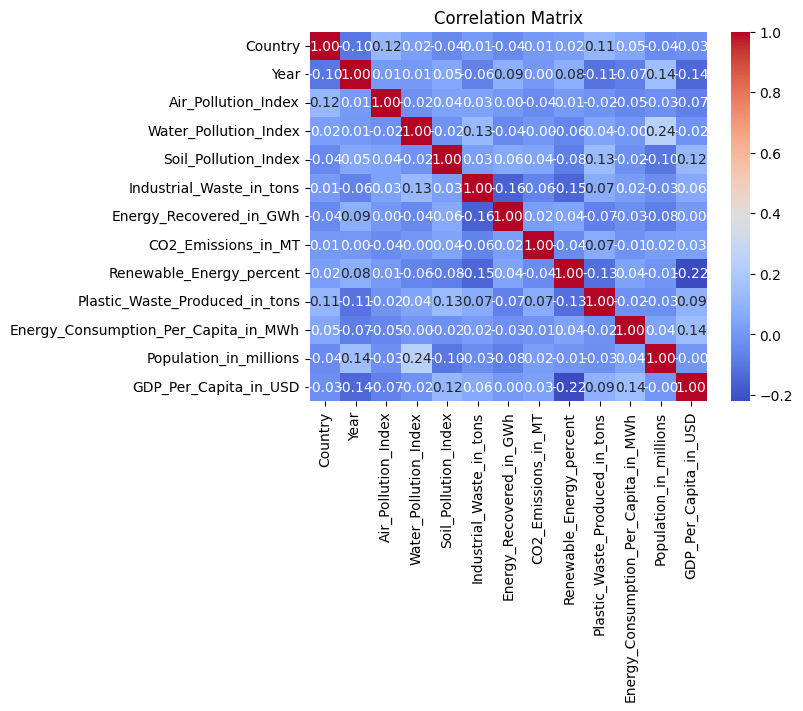

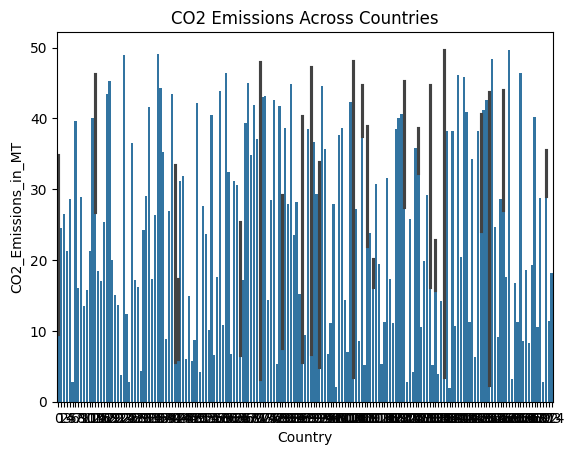

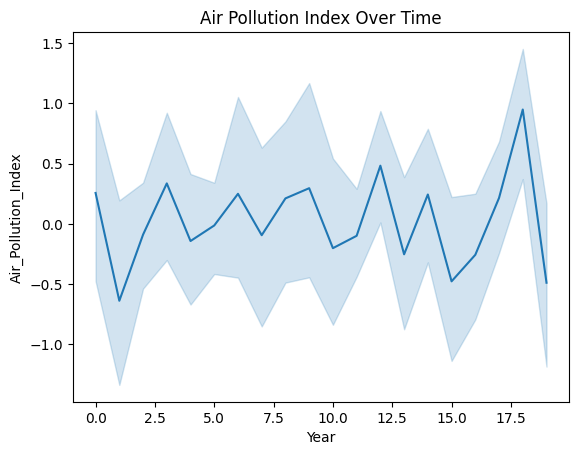

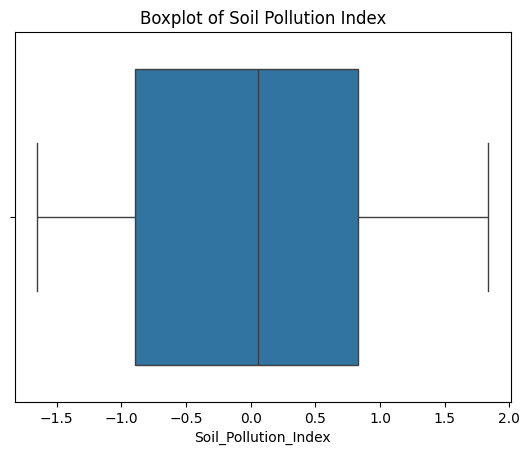

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
Year                                                                  
0                0.256617               0.072583             -0.181989
1               -0.637654              -0.655996             -0.130036
2               -0.089162               0.180136             -0.028892
3                0.335938               0.379503              0.611174
4               -0.142082               0.119064             -0.164913
5               -0.013018              -0.143753             -0.090079
6                0.249602              -0.001084              0.609314
7               -0.093832              -0.160204             -0.524592
8                0.211581              -0.272931             -0.024751
9                0.296135              -0.337705             -0.189288
10              -0.201302               0.712034              0.505456
11              -0.098808               0.257348             -0.641096
12    

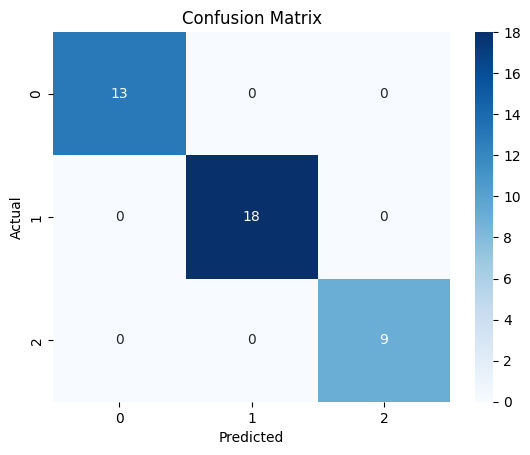

Linear Regression Metrics:
MSE: 98520.29238652943
R²: -182443.98590098042

Logistic Regression Metrics:
Accuracy: 1.0


c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Phase 1: Data Collection and Exploratory Data Analysis (EDA)
# Step 1 - Data Import and Preprocessing

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
print(data.info())

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Display the first few rows
print(data.head())

# Data Transformation
# Normalize or scale pollution indices (air, water, and soil)
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features (Country and Year)
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Step 2 - Exploratory Data Analysis (EDA)
# Descriptive Statistics
print(data.describe())

# Correlation Analysis
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Visualizations
# Bar chart of CO2 Emissions across countries
sns.barplot(x=data['Country'], y=data['CO2_Emissions_in_MT'])
plt.title('CO2 Emissions Across Countries')
plt.show()

# Line plot of Air Pollution Index over years
sns.lineplot(data=data, x='Year', y='Air_Pollution_Index')
plt.title('Air Pollution Index Over Time')
plt.show()

# Box plot for Soil Pollution Index
sns.boxplot(x=data['Soil_Pollution_Index'])
plt.title('Boxplot of Soil Pollution Index')
plt.show()

# Step 3 - Feature Engineering
# Yearly Trends: Calculate mean pollution levels per year
yearly_trends = data.groupby('Year')[pollution_columns].mean()
print(yearly_trends)

# Energy Consumption per Capita: Calculate energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita_in_MWh'] / data['Population_in_millions']

# Phase 2: Predictive Modeling
# Step 4 - Linear Regression Model (for Pollution Prediction)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Objective: Predict Energy Recovery from Pollution Levels
# Feature-target split
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT', 'Energy_Consumption_Per_Capita']]
y = data['Energy_Recovered_in_GWh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Step 5 - Logistic Regression Model (for Categorization of Pollution Levels)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Binarize target variable: Categorize pollution severity (Low, Medium, High)
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_log = log_reg.predict(X_test)

# Evaluate the logistic regression model
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 3: Reporting and Insights
# Step 6 - Model Evaluation and Comparison
# Compare Linear Regression and Logistic Regression models based on their performance and metrics.
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))

# Step 7 - Actionable Insights
# Insights based on the models:
# - Identify countries with the highest pollution levels and low energy recovery potential.
# - Suggest strategies for improving energy recovery by targeting high-pollution countries.
# - Discuss potential benefits of transitioning to renewable energy sources for countries with high pollution.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               200 non-null    object 
 1   Year                                  200 non-null    int64  
 2   Air_Pollution_Index                   200 non-null    float64
 3   Water_Pollution_Index                 200 non-null    float64
 4   Soil_Pollution_Index                  200 non-null    float64
 5   Industrial_Waste_in_tons              200 non-null    float64
 6   Energy_Recovered_in_GWh               200 non-null    float64
 7   CO2_Emissions_in_MT                   200 non-null    float64
 8   Renewable_Energy_percent              200 non-null    float64
 9   Plastic_Waste_Produced_in_tons        200 non-null    float64
 10  Energy_Consumption_Per_Capita_in_MWh  200 non-null    float64
 11  Population_in_milli

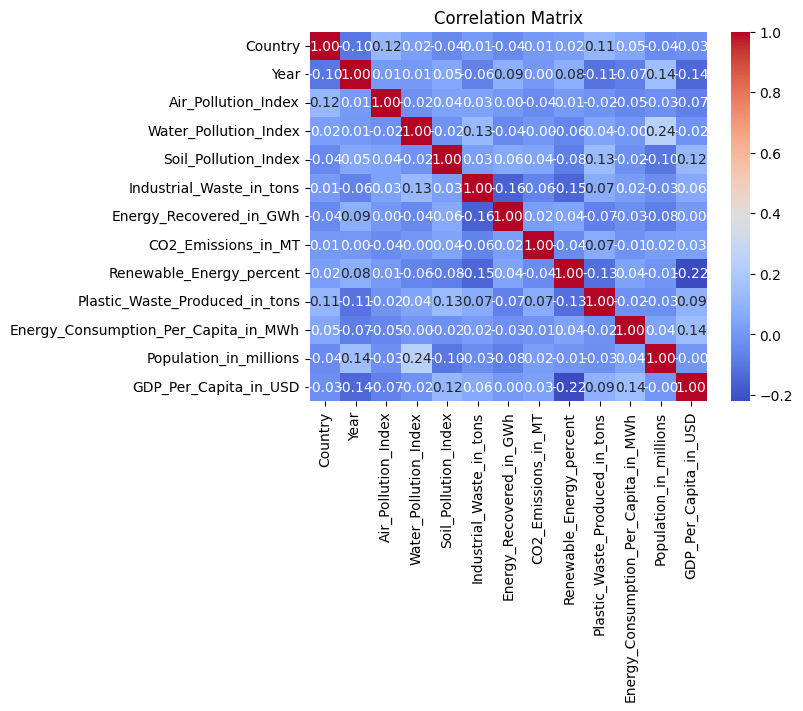

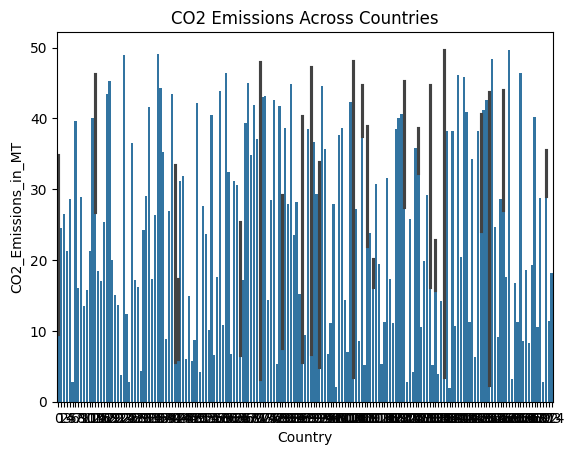

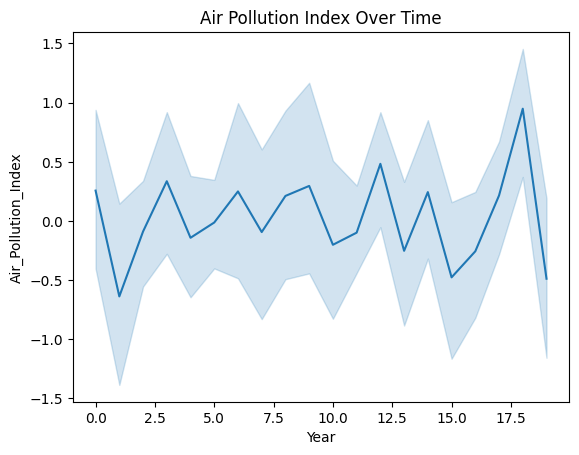

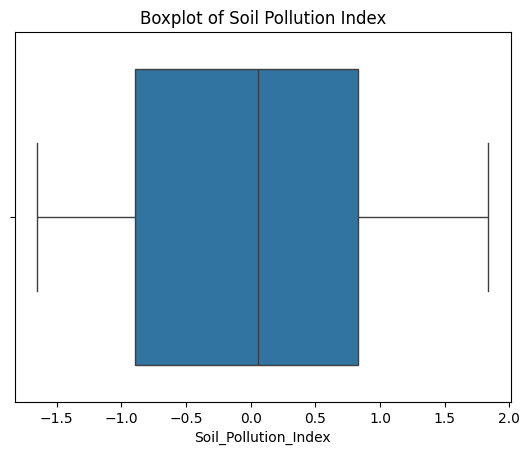

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
Year                                                                  
0                0.256617               0.072583             -0.181989
1               -0.637654              -0.655996             -0.130036
2               -0.089162               0.180136             -0.028892
3                0.335938               0.379503              0.611174
4               -0.142082               0.119064             -0.164913
5               -0.013018              -0.143753             -0.090079
6                0.249602              -0.001084              0.609314
7               -0.093832              -0.160204             -0.524592
8                0.211581              -0.272931             -0.024751
9                0.296135              -0.337705             -0.189288
10              -0.201302               0.712034              0.505456
11              -0.098808               0.257348             -0.641096
12    

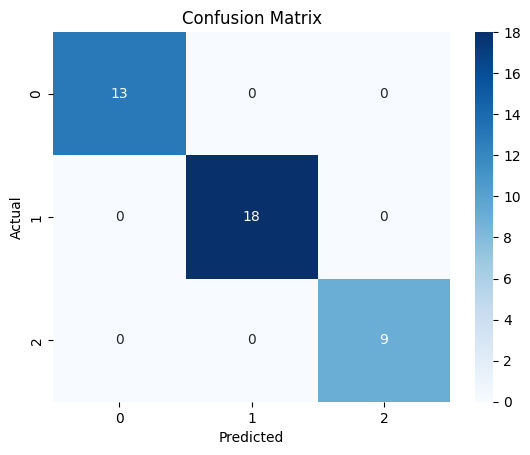

Linear Regression Metrics:
MSE: 69700.93879634453
R²: -129074.8125858232

Logistic Regression Metrics:
Accuracy: 1.0


In [10]:
# Phase 1: Data Collection and Exploratory Data Analysis (EDA)
# Step 1 - Data Import and Preprocessing

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
print(data.info())

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Display the first few rows
print(data.head())

# Data Transformation
# Normalize or scale pollution indices (air, water, and soil)
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features (Country and Year)
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Step 2 - Exploratory Data Analysis (EDA)
# Descriptive Statistics
print(data.describe())

# Correlation Analysis
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Visualizations
# Bar chart of CO2 Emissions across countries
sns.barplot(x=data['Country'], y=data['CO2_Emissions_in_MT'])
plt.title('CO2 Emissions Across Countries')
plt.show()

# Line plot of Air Pollution Index over years
sns.lineplot(data=data, x='Year', y='Air_Pollution_Index')
plt.title('Air Pollution Index Over Time')
plt.show()

# Box plot for Soil Pollution Index
sns.boxplot(x=data['Soil_Pollution_Index'])
plt.title('Boxplot of Soil Pollution Index')
plt.show()

# Step 3 - Feature Engineering
# Yearly Trends: Calculate mean pollution levels per year
yearly_trends = data.groupby('Year')[pollution_columns].mean()
print(yearly_trends)

# Energy Consumption per Capita: Calculate energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita_in_MWh'] / data['Population_in_millions']

# Phase 2: Predictive Modeling
# Step 4 - Linear Regression Model (for Pollution Prediction)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Objective: Predict Energy Recovery from Pollution Levels
# Feature-target split
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT', 'Energy_Consumption_Per_Capita']]
y = data['Energy_Recovered_in_GWh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))
# Step 5 - Logistic Regression Model (for Categorization of Pollution Levels)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Binarize target variable: Categorize pollution severity (Low, Medium, High)
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Column transformer to scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
                                      'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT', 'Energy_Consumption_Per_Capita'])
    ])

# Logistic Regression Model within a pipeline
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Train the logistic regression model
log_reg.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_log = log_reg.predict(X_test)

# Evaluate the logistic regression model
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 3: Reporting and Insights
# Step 6 - Model Evaluation and Comparison
# Compare Linear Regression and Logistic Regression models based on their performance and metrics.
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))

# Step 7 - Actionable Insights
# Insights based on the models:
# - Identify countries with the highest pollution levels and low energy recovery potential.
# - Suggest strategies for improving energy recovery by targeting high-pollution countries.
# - Discuss potential benefits of transitioning to renewable energy sources for countries with high pollution. 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               200 non-null    object 
 1   Year                                  200 non-null    int64  
 2   Air_Pollution_Index                   200 non-null    float64
 3   Water_Pollution_Index                 200 non-null    float64
 4   Soil_Pollution_Index                  200 non-null    float64
 5   Industrial_Waste_in_tons              200 non-null    float64
 6   Energy_Recovered_in_GWh               200 non-null    float64
 7   CO2_Emissions_in_MT                   200 non-null    float64
 8   Renewable_Energy_percent              200 non-null    float64
 9   Plastic_Waste_Produced_in_tons        200 non-null    float64
 10  Energy_Consumption_Per_Capita_in_MWh  200 non-null    float64
 11  Population_in_milli

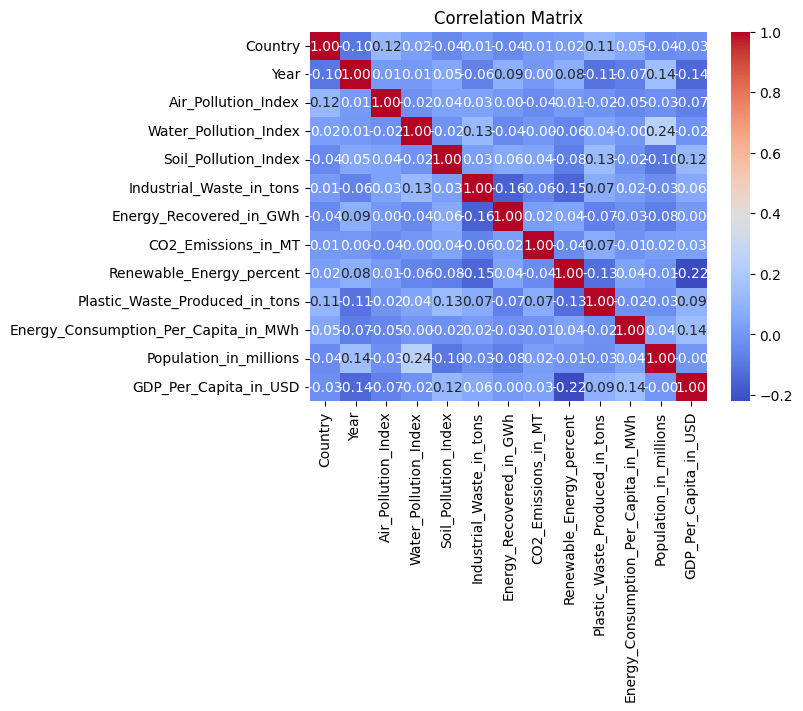

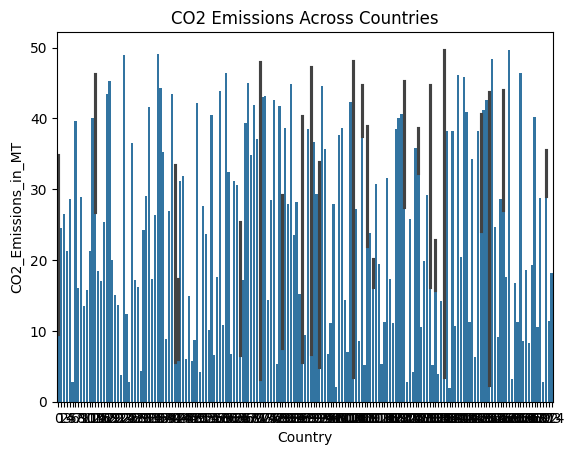

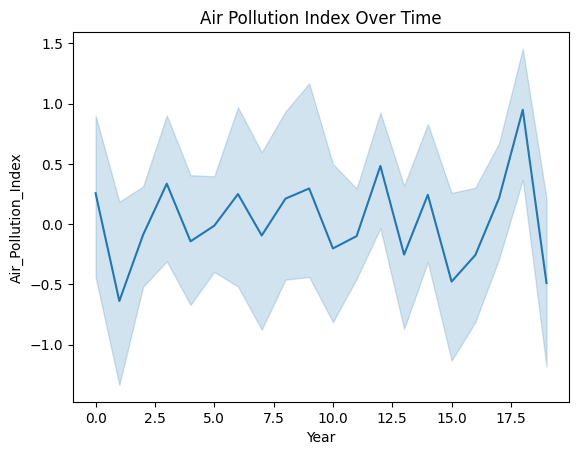

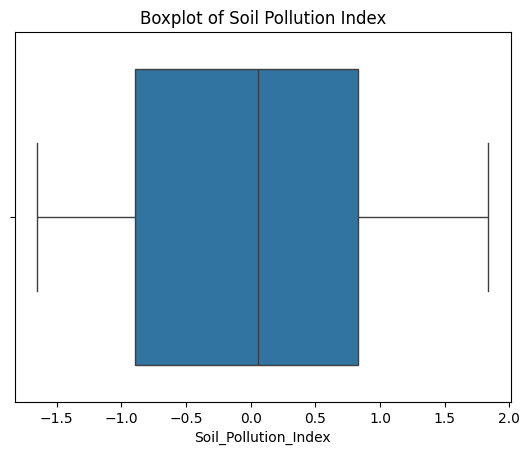

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
Year                                                                  
0                0.256617               0.072583             -0.181989
1               -0.637654              -0.655996             -0.130036
2               -0.089162               0.180136             -0.028892
3                0.335938               0.379503              0.611174
4               -0.142082               0.119064             -0.164913
5               -0.013018              -0.143753             -0.090079
6                0.249602              -0.001084              0.609314
7               -0.093832              -0.160204             -0.524592
8                0.211581              -0.272931             -0.024751
9                0.296135              -0.337705             -0.189288
10              -0.201302               0.712034              0.505456
11              -0.098808               0.257348             -0.641096
12    

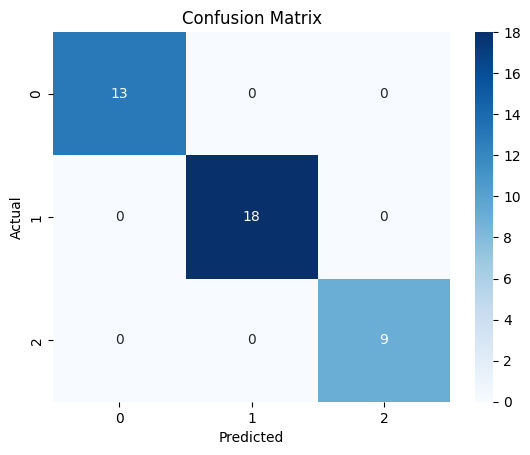

Logistic Regression - Cross-validated Accuracy: 0.9550000000000001

Comparing Linear Regression and Logistic Regression:

Linear Regression Metrics:
MSE: 20.330851116550996
R²: -36.64972428990925

Logistic Regression Metrics:
Accuracy: 1.0


In [11]:
# Phase 1: Data Collection and Exploratory Data Analysis (EDA)
# Step 1 - Data Import and Preprocessing

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
print(data.info())

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Display the first few rows
print(data.head())

# Data Transformation
# Normalize or scale pollution indices (air, water, and soil)
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features (Country and Year)
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Step 2 - Exploratory Data Analysis (EDA)
# Descriptive Statistics
print(data.describe())

# Correlation Analysis
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Visualizations
# Bar chart of CO2 Emissions across countries
sns.barplot(x=data['Country'], y=data['CO2_Emissions_in_MT'])
plt.title('CO2 Emissions Across Countries')
plt.show()

# Line plot of Air Pollution Index over years
sns.lineplot(data=data, x='Year', y='Air_Pollution_Index')
plt.title('Air Pollution Index Over Time')
plt.show()

# Box plot for Soil Pollution Index
sns.boxplot(x=data['Soil_Pollution_Index'])
plt.title('Boxplot of Soil Pollution Index')
plt.show()

# Step 3 - Feature Engineering
# Yearly Trends: Calculate mean pollution levels per year
yearly_trends = data.groupby('Year')[pollution_columns].mean()
print(yearly_trends)

# Energy Consumption per Capita: Calculate energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita_in_MWh'] / data['Population_in_millions']

# Phase 2: Predictive Modeling
# Step 4 - Linear Regression Model (for Pollution Prediction)
# Log transform the target variable (Energy_Recovered_in_GWh)
data['Log_Energy_Recovered_in_GWh'] = np.log1p(data['Energy_Recovered_in_GWh'])

# Feature-target split for linear regression
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT', 'Energy_Consumption_Per_Capita']]
y = data['Log_Energy_Recovered_in_GWh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Cross-validation for Linear Regression
cv_scores_lr = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_squared_error')
print("Linear Regression - Cross-validated MSE:", -cv_scores_lr.mean())

# Step 5 - Logistic Regression Model (for Categorization of Pollution Levels)
# Binarize target variable: Categorize pollution severity (Low, Medium, High)
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Scale features for logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Logistic Regression Model with class weights (if imbalance exists)
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_log = log_reg.predict(X_test)

# Evaluate the logistic regression model
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross-validation for Logistic Regression
cv_scores_log = cross_val_score(log_reg, X_scaled, y_class, cv=5, scoring='accuracy')
print("Logistic Regression - Cross-validated Accuracy:", cv_scores_log.mean())

# Phase 3: Reporting and Insights
# Step 6 - Model Evaluation and Comparison
print("\nComparing Linear Regression and Logistic Regression:")
# Linear Regression metrics
print("\nLinear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Logistic Regression metrics
print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Step 7 - Actionable Insights
# Insights based on the models:
# - Identify countries with the highest pollution levels and low energy recovery potential.
# - Suggest strategies for improving energy recovery by targeting high-pollution countries.
# - Discuss potential benefits of transitioning to renewable energy sources for countries with high pollution.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               200 non-null    object 
 1   Year                                  200 non-null    int64  
 2   Air_Pollution_Index                   200 non-null    float64
 3   Water_Pollution_Index                 200 non-null    float64
 4   Soil_Pollution_Index                  200 non-null    float64
 5   Industrial_Waste_in_tons              200 non-null    float64
 6   Energy_Recovered_in_GWh               200 non-null    float64
 7   CO2_Emissions_in_MT                   200 non-null    float64
 8   Renewable_Energy_percent              200 non-null    float64
 9   Plastic_Waste_Produced_in_tons        200 non-null    float64
 10  Energy_Consumption_Per_Capita_in_MWh  200 non-null    float64
 11  Population_in_milli

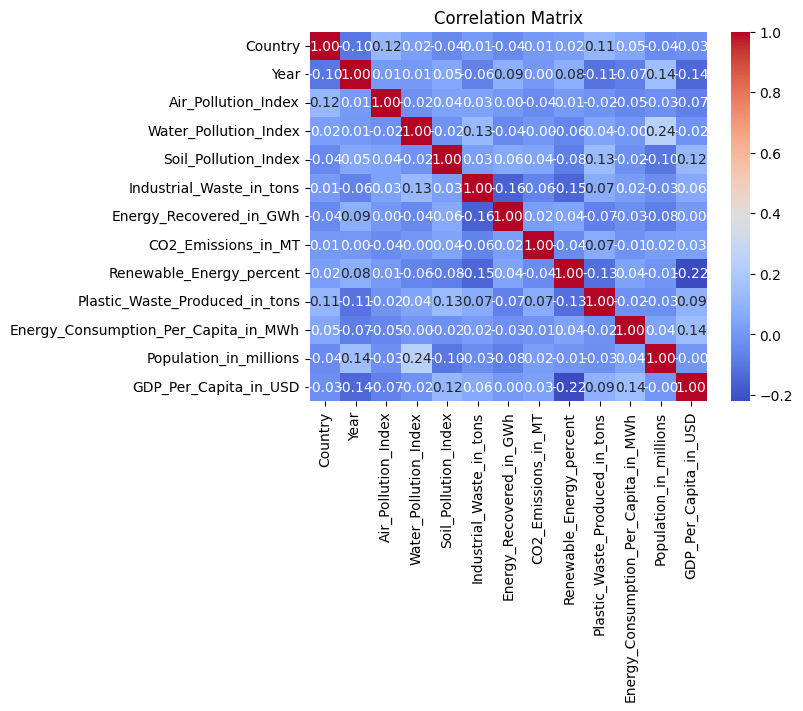

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
Year                                                                  
0                0.256617               0.072583             -0.181989
1               -0.637654              -0.655996             -0.130036
2               -0.089162               0.180136             -0.028892
3                0.335938               0.379503              0.611174
4               -0.142082               0.119064             -0.164913
5               -0.013018              -0.143753             -0.090079
6                0.249602              -0.001084              0.609314
7               -0.093832              -0.160204             -0.524592
8                0.211581              -0.272931             -0.024751
9                0.296135              -0.337705             -0.189288
10              -0.201302               0.712034              0.505456
11              -0.098808               0.257348             -0.641096
12    

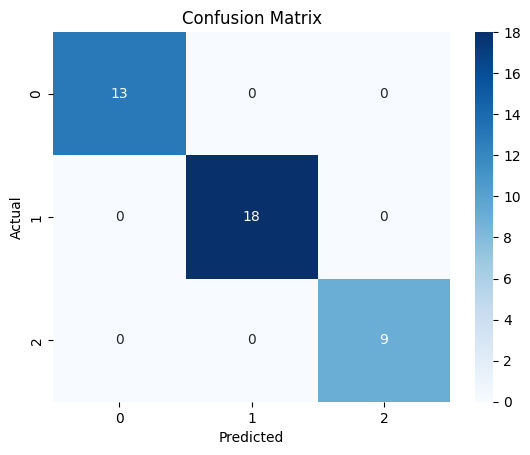

Logistic Regression - Cross-validated Accuracy: 0.9550000000000001

Linear Regression Metrics:
MSE: 69579.89571030921
R²: -128850.65872279483

Logistic Regression Metrics:
Accuracy: 1.0


In [13]:
# Phase 1: Data Collection and Exploratory Data Analysis (EDA)
# Step 1 - Data Import and Preprocessing

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import PolynomialFeatures

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
print(data.info())

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Display the first few rows
print(data.head())

# Data Transformation
# Normalize or scale pollution indices (air, water, and soil)
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features (Country and Year)
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Step 2 - Exploratory Data Analysis (EDA)
# Descriptive Statistics
print(data.describe())

# Correlation Analysis
numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Step 3 - Feature Engineering
# Yearly Trends: Calculate mean pollution levels per year
yearly_trends = data.groupby('Year')[pollution_columns].mean()
print(yearly_trends)

# Energy Consumption per Capita: Calculate energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita_in_MWh'] / data['Population_in_millions']

# Phase 2: Predictive Modeling
# Step 4 - Linear Regression Model (for Pollution Prediction)
# Feature-target split
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT', 'Energy_Consumption_Per_Capita']]
y = data['Energy_Recovered_in_GWh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features to improve model performance
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_poly, y_train)

# Predictions and Evaluation for Linear Regression
y_pred_lr = lr_model.predict(X_test_poly)

# Evaluate the Linear Regression Model
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Step 5 - Logistic Regression Model (for Categorization of Pollution Levels)
# Binarize target variable: Categorize pollution severity (Low, Medium, High)
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Logistic Regression with L2 regularization
log_reg = LogisticRegression(penalty='l2', max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predictions and Evaluation for Logistic Regression
y_pred_log = log_reg.predict(X_test)

# Evaluate the Logistic Regression Model
print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross-validation for Logistic Regression
cv_scores = cross_val_score(log_reg, X_scaled, y_class, cv=5, scoring='accuracy')
print(f"Logistic Regression - Cross-validated Accuracy: {cv_scores.mean()}")

# Phase 3: Reporting and Insights
# Step 6 - Model Evaluation and Comparison
# Compare Linear Regression and Logistic Regression models based on their performance and metrics.

y_pred_lr = lr_model.predict(X_test_poly)

# Linear Regression Metrics
print("\nLinear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))

# Step 7 - Actionable Insights
# Insights based on the models:
# - Identify countries with the highest pollution levels and low energy recovery potential.
# - Suggest strategies for improving energy recovery by targeting high-pollution countries.
# - Discuss potential benefits of transitioning to renewable energy sources for countries with high pollution.



Linear Regression Metrics:

LinearRegression:
MSE: 22742.516145251506
MAE: 133.00141144335208
R²: 0.0595362808098141

Ridge:
MSE: 22745.54909404065
MAE: 133.1233716351828
R²: 0.05941086028553555

Lasso:
MSE: 22764.145775755387
MAE: 133.19847390317028
R²: 0.058641837881051484

Logistic Regression Metrics:
Accuracy: 0.9215686274509803
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.78      0.88        18
           2       0.85      1.00      0.92        17

    accuracy                           0.92        51
   macro avg       0.93      0.93      0.92        51
weighted avg       0.93      0.92      0.92        51



c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=8.35126e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


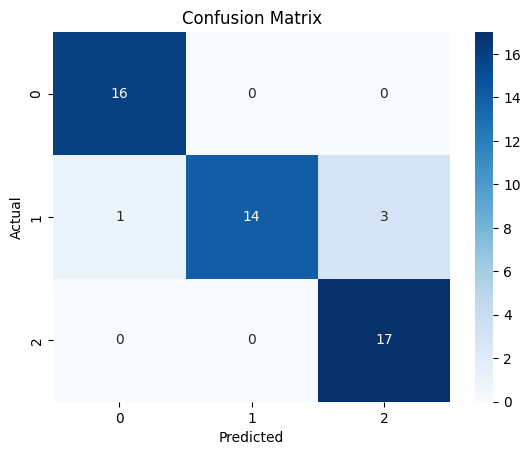


Logistic Regression - Cross-validated Accuracy: 0.9167058823529413


c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c

In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Handle missing values
data.fillna(data.median(numeric_only=True), inplace=True)

# Normalize pollution indices and other numerical features
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Feature-target split for Linear Regression
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT']]
y_reg = data['Energy_Recovered_in_GWh']

# Add Polynomial Features for Linear Regression
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y_reg, test_size=0.2, random_state=42)

# Linear Regression with Regularization (Ridge and Lasso)
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

print("\nLinear Regression Metrics:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# Binarize target for Logistic Regression
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_class)

# Scale the resampled features
X_rescaled = scaler.fit_transform(X_resampled)

# Train-test split for Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(X_rescaled, y_resampled, test_size=0.2, random_state=42)

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='ovr')
log_reg.fit(X_train, y_train)

# Predictions and evaluation
y_pred_log = log_reg.predict(X_test)

print("\nLogistic Regression Metrics:")
print("Accuracy:", log_reg.score(X_test, y_test))
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross-validation score for Logistic Regression
cv_score = cross_val_score(log_reg, X_rescaled, y_resampled, cv=5, scoring='accuracy')
print("\nLogistic Regression - Cross-validated Accuracy:", cv_score.mean())


In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load the dataset
file_path = 'Global_Pollution_Analysis.csv'
data = pd.read_csv(file_path)

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Normalize pollution indices
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = StandardScaler()
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Encode categorical features
label_enc = LabelEncoder()
data['Country'] = label_enc.fit_transform(data['Country'])
data['Year'] = label_enc.fit_transform(data['Year'])

# Feature-target split for regression
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'CO2_Emissions_in_MT']]
y = data['Energy_Recovered_in_GWh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Linear Regression Metrics
print("\nLinear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Ridge Regression
ridge_model = Ridge(alpha=10.0)  # Adjusted alpha for stability
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

print("\nRidge Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print("\nLasso Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("R²:", r2_score(y_test, y_pred_lasso))

# Logistic Regression: Categorizing Pollution Levels
# Binarize target variable
pollution_severity = pd.cut(data['Air_Pollution_Index'], bins=3, labels=[0, 1, 2])
y_class = pollution_severity

# Rescale features
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train_class, y_test_class = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs'))
log_reg.fit(X_train, y_train_class)
y_pred_log = log_reg.predict(X_test)

# Logistic Regression Metrics
print("\nLogistic Regression Metrics:")
print("Accuracy:", log_reg.score(X_test, y_test_class))
print("Classification Report:")
print(classification_report(y_test_class, y_pred_log))

# Cross-validation for Logistic Regression
cv_score = cross_val_score(log_reg, X_scaled, y_class, cv=5, scoring='accuracy')
print("\nLogistic Regression - Cross-validated Accuracy:", cv_score.mean())



Linear Regression Metrics:
MSE: 24538.059908635663
MAE: 141.345969590013
R²: -0.014714244281429423

Ridge Regression Metrics:
MSE: 24496.644127532974
MAE: 141.26772597942934
R²: -0.013001591236347032

Lasso Regression Metrics:
MSE: 24532.872845768557
MAE: 141.34190174643567
R²: -0.014499745392893226

Logistic Regression Metrics:
Accuracy: 0.975
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.95      1.00      0.97        18
           2       1.00      1.00      1.00         9

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40


Logistic Regression - Cross-validated Accuracy: 0.925
